In [2]:
from langgraph.graph import StateGraph,START,END
from langgraph.types import Send
from typing import TypedDict,Annotated,List
from pydantic import BaseModel,Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage,HumanMessage
from pathlib import Path
import operator
import re

In [3]:
class Task(BaseModel):
    id : int
    title : str
    goal : str = Field(...,description="one sentence describing what the reader should be able to do/understand after this section.")
    bullets : List[str] = Field(...,min_length=3,max_length=5,description="3-5 concrete,non-overlapping subpoints to cover in this section")
    target_words : int = Field(...,description="Target word count for this section (120-450).")
    section_type : int = Field(...,description="use 'common-mistakes' exactl once in this plan")
    brief : str = Field(...,description="what to cover")

In [4]:
class Plan(BaseModel):
    blog_title : str
    audience : str = Field(...,description="who the blog is for")
    tone : str = Field(...,description="writing tone (e.g.,practical,crisp)")
    tasks : List[Task]

In [5]:
class AgentState(TypedDict):
    topic : str
    plan : Plan
    sections : Annotated[List[str],operator.add]
    final : str

In [6]:
llm = ChatGoogleGenerativeAI(model='gemini-3.5-flash-lite')

In [7]:
def orchestrator(state:AgentState)->AgentState:
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(content=
            "You are a Senior technial writer and developer advocate. you job is to produce a highly actionable outline for a technical blog post.\n\n"
            "Hard requirements:\n"
            "- Create 5-7 sections (tasks) that for a technical blog.\n"
            "- Each section must include :\n"
            "1) goal (1 sentence : what the reader ca do/un after the section)\n"
            "2) 3-5 bullets that are concrete,specific and non-overlapping \n"
            "3) target word count(120-450) \n"
            "- Include exactly one section with section-type = 'common-mistakes'"
            "Make it technical (not generic) :\n"
            "- Assume the reader is a developer : use correct terminology.\n"
            "- Prefer design/engineering structure :problem --> intution --> approach --> implementation --> trade-off --> testing/observability --> conclusion\n"
            "- Bullets must be actionable and testable(e.g., 'show a minimal code snippet of X','Explain why Y fails under Z condition','Add a checklist for production readiness')\n"
            "- Explicitly include at least one of the following somewhere in the plan (as bullets):\n"
            "* a minimal working example(MWE) or code sketch\n"
            "* edge cases / feature notes\n"
            "* performace / cost consideration\n"
            "* security/privacy consideration\n"
            "* debugging tips / observability (log,metrics,tracer)\n"
            "- Avoid Valgure bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what to build/compare/measure .\n\n"
            "Ordering guidance : \n"
            "- Start with a crisp intro and problem framing.\n"
            "- Build core concepts before advance details \n"
            "- Include one section for common mistakes and how to avoid them.\n"
            "- End with a practical summary/checklist and next steps\n\n"
            "output must strictly match the plan schema"
            ),
            HumanMessage(content=f'Topic:{state['topic']}')
        ]
    )
    return {'plan':plan}

In [8]:
def fanout(state:AgentState):
    return [
        Send("worker",{"task":task,"topic":state['topic'],"plan":state['plan']}) for task in state['plan'].tasks
    ]

In [9]:
def worker(payload:dict)->dict:
    task = payload['task']
    topic = payload['topic']
    plan = payload['plan']
    blog_title = plan.blog_title
    section_md = llm.invoke([
        SystemMessage(content=
        "You are a senior techinal writer and developer advocate. write one section of a technical blog post in markdown."
        "Hard Constraints : \n"
        "- Follow the provided goal and cover all bullets in order (donot skip or merge bullets).\n"
        "- stay close to the target words(+-15%).\n"
        "- output only the section content in Markdown (no blog title H1 , no extra commentory)\n\n"
        "Techinical quality bar:\n"
        "- Be precise and implementation oriented(developers should be able to apply it).\n"
        "- Prefer concreate details over abstractions : APIS,data structures,protocalls and exact terms\n"
        "- when relevant, include at least one of :\n"
        "* a small code snippet(minimal,correct,idiomatic)\n"
        "* a tiny example input/output \n"
        "* a checklist of steps\n"
        "* a diagram described in text (eg.,'Flow : A -> B-> C')\n"
        "- Explain trade-offs briefly(performance,cost,complexity,reliability)\n"
        "- call out edge cases/ failure mods and what to do about them.\n"
        "- If you mention a best practice,add the 'why' in one sentence.\n\n"
        "Markdown style : \n"
        "- Start with a '##<Section Title>' heading.\n"
        "- use short paragraphs,bullet lists where helpful and code references for code.\n"
        "-Avoid fluff. Avoid Marketing Vanguans .\n"
        "- If you include code , keep a focused on the bullet being addressed.\n"
                      ),
        HumanMessage(content=(
            f"Blog: {blog_title}\n"
            f"Topic: {topic}\n\n"
            f"section : {task.title}\n"
            f"Brief : {task.brief} \n\n"
            "return only the section content in markdown."
        ))
    ]).content[0]['text'].strip()
    return {"sections":[section_md]}


In [10]:
def reducer(state:AgentState)->AgentState:
    title = state['plan'].blog_title
    body = "\n\n".join(state["sections"]).strip()
    final_md = f'# {title}\n\n{body}\n'
    # Save the file locally
    filename = re.sub(r'[^a-zA-Z0-9\s-]', '', title)
    filename = re.sub(r'\s+', '_', filename).strip('_').lower()[:100] + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md,encoding="utf-8")
    return {'final':final_md}

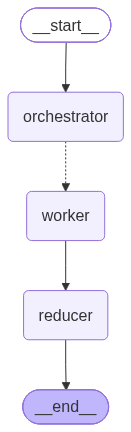

In [11]:
graph = StateGraph(AgentState)
graph.add_node('orchestrator',orchestrator)
graph.add_node('worker',worker)
graph.add_node('reducer',reducer)
graph.add_edge(START,'orchestrator')
graph.add_conditional_edges('orchestrator',fanout,['worker'])
graph.add_edge('worker','reducer')
graph.add_edge('reducer',END)
workflow = graph.compile()
workflow

In [12]:
initial_state = {'topic':'write a blog on self attention'}
final_state = workflow.invoke(initial_state)
final_state

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'topic': 'write a blog on self attention',
 'plan': Plan(blog_title='Demystifying Self-Attention: A Developer Guide to Implementing and Optimizing Transformer Core', audience='Software engineers and machine learning practitioners building custom neural network architectures', tone='practical,crisp', tasks=[Task(id=1, title='Problem Framing and Mathematical Intuition', goal='Understand why recurrent architectures fail on long sequences and how self-attention solves the parallelization bottleneck.', bullets=['Contrast sequential processing in RNNs/LSTMs with all-to-all token connectivity in self-attention', 'Define the operational mechanics of Queries (Q), Keys (K), and Values (V) using a database lookup analogy', 'Walk through the dimension math for embedding vectors projecting into Q, K, and V weight matrices'], target_words=250, section_type=1, brief='Establish the fundamental limitations of recurrence and introduce the QKV vector abstraction.'), Task(id=2, title='Implementing Scaled